# <p style="text-align:center;">Forecasting grid failures</p>


In [1]:
from google.cloud import bigquery
from google.cloud import storage
import numpy as np
import pandas as pd
import geopandas as gpd
import datetime as dt
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import ScalarFormatter, MultipleLocator
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from decimal import *
from calendar import monthrange, month_abbr
import cartopy as ctp
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt
from cartopy.io import shapereader
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import io
import base64
import pygrib
import math
import netCDF4
import pytz
import cmocean
import seaborn as sns
from sklearn.metrics import mean_squared_error, confusion_matrix
import matplotlib.dates as mdates
from pytz import timezone, all_timezones
from scipy.stats import spearmanr, pearsonr, linregress
import scipy.signal as signal
from scipy.interpolate import interp1d
from taylor_diagram import TaylorDiagram
import statsmodels.api as sm
import os
import difflib
import folium
from folium.plugins import MarkerCluster, BeautifyIcon
from PIL import Image, ImageDraw
import warnings
import properscoring as ps
import numba
import pprint
from geopy.distance import geodesic
import xarray as xr

In [2]:
# import class and functions from other scripts
import datasets_forecast as ds

In [3]:
plt.rcParams['text.usetex'] = True

## Load datasets

### load

In [4]:
def get_timeseries_load(fname):

    # Load the dataset
    dataset = pd.read_csv(fname)

    # Convert the 'orario' column to datetime
    dataset['orario'] = pd.to_datetime(dataset['orario'], utc=True)

    # change names
    dataset.rename(columns={'orario':'VALID_DATE', 'load_mwh':'LOAD'}, inplace=True)

    return dataset

In [5]:
load_2023 = get_timeseries_load('load_CP_MI_2023.csv')
load_summer_2023 = load_2023[(load_2023['VALID_DATE'].dt.date >= dt.date(2023, 6, 1)) & (load_2023['VALID_DATE'].dt.date <= dt.date(2023, 8, 31))]

In [6]:
display(load_summer_2023.head(6))

,VALID_DATE,LOAD
3625,2023-06-01 00:00:00+00:00,452.169810
3626,2023-06-01 01:00:00+00:00,442.488250
3627,2023-06-01 02:00:00+00:00,444.775214
3628,2023-06-01 03:00:00+00:00,471.990952
3629,2023-06-01 04:00:00+00:00,548.730667
3630,2023-06-01 05:00:00+00:00,653.958833


### failures

In [7]:
def get_guasti(fname, dstart, dend):

    # Load the dataset
    colnames = ['Data di guasto','OdL padre','Scatto','Rete','Impianto','Cavo',
                'Tratto cavo / da cabina elemento di rete presunto sede di guasto',
                'Tipo','da cabina','a cabina','Numero Nodo GIS - Solo rete 23 Kv giunti 12/20',
                'Priorità','Criticità','Fase lavorativa','Ricerca guasto','Impresa scavo','Riparazione',
                'Indirizzo dell\'intervento','Causa accertata','Intervento eseguito','Data rientro',
                'Note esercizio','Note fasi lavorative','Mese guasto','Mese riparazione','Anno',
                'Raggruppamento causa accertata','Origine','Agregazione impianto','verifica data']
    dataset = pd.read_excel(fname, sheet_name='Monitoraggio', header=None, names=colnames)

    # Convert the 'Data di guasto' column to datetime
    dataset['Data di guasto'] = pd.to_datetime(dataset['Data di guasto'], format='%d/%m/%Y', errors='coerce')
    dataset['Mese guasto'] = pd.to_datetime(dataset['Mese guasto'], format='%B', errors='coerce').dt.month
    dataset['Data rientro'] = pd.to_datetime(dataset['Data rientro'], format='%d/%m/%Y', errors='coerce')

    # localize to Europe/Rome
    dataset['Data di guasto'] = dataset['Data di guasto'].dt.tz_localize('Europe/Rome')
    dataset['Data rientro'] = dataset['Data rientro'].dt.tz_localize('Europe/Rome')

    # filter 
    dataset = dataset[(dataset['Data di guasto'].dt.date >=dstart) & (dataset['Data di guasto'].dt.date <= dend)]

    # 'da cabina' and 'a cabina' as string, remove spaces around
    dataset['da cabina'] = dataset['da cabina'].astype(str).str.strip()
    dataset['a cabina'] = dataset['a cabina'].astype(str).str.strip()

    # fill missing values in 'Causa accertata' with 'NON ACCERTATA'
    dataset['Causa accertata'] = dataset['Causa accertata'].fillna('NON ACCERTATA')

    # remove some causes
    irrelevant_causes=['NO GUASTO', 'COMPETENZA ENEL', 'PROVA DI TENSIONE OK', 'RIFACIMENTO GIUNTI 20KV']
    dataset = dataset[~dataset['Causa accertata'].isin(irrelevant_causes)]

    # group causes
    groupcause = {'joint':['AG AUTORETRAIBILE 20kV','AG TERMO-RESTRINGENTI 20kV','AG 9kV (miscela a caldo)','AG BICOMPONENTE 9kV (miscela a freddo)',
                           'AG 23kV (vecchio tipo)','AG CAVO PRECORDATO','AG RESINA','AG AUTORETRAIBILE 30kV', 'AG AUTORETR. 30KV + CELLA'],
                  'cable':['CAVO DETERIORATO','CAVO DANNEGGIATO','CAVO INTACCATO', 'CAVO DETERIORATO + CELLA LINEA'],
                  'cabin':['CABINA','TERMINALE RAICHEM','TERMINALE VETRO','CELLA LINEA','CELLA UTENTE','TERMINALE SILICONICO','TRASFORMATORE','2962 CELLA',
                           'TERMINALI + CELLA LINEA','TERMINALI ','TERMINALI','CELLA TRAFO','TERMINALE','TERMINALE + CELLA LINEA', 'TERMINALE+CELLA',
                           'CELLA TRAFO + CELLA CONGIUNTORE'],
                  'other':['DANNI', 'DANNI DA INCENDIO','SEZIONATORE A PALO', 'NON ACCERTATA']
                  }
    dataset['Causegroup'] = dataset['Causa accertata'].apply(lambda x: 'cable' if x in groupcause['cable'] else ('cabin' if x in groupcause['cabin'] else ('joint' if x in groupcause['joint'] else 'other')))
    dataset['Causegroup'] = dataset['Causegroup'].astype('category')


    return dataset

In [8]:
guasti_2012_2024 = get_guasti('pri_raw_pri_2023-12-11.xlsx', dt.date(2012, 1, 1), dt.date(2024, 12, 31))
#print(guasti_2012_2024.columns)
#print(guasti_2012_2024.shape)

In [9]:
#with pd.option_context('display.max_rows', None, 'display.max_columns', None,'display.max_colwidth', None):
    #display(guasti_2012_2024.tail(100))
    #display(guasti_2012_2024[guasti_2012_2024['Tratto cavo / da cabina elemento di rete presunto sede di guasto']=='234-2048'].head(100))	
    #display(guasti_2012_2024['Scatto'].unique())
    #display(len(guasti_2012_2024['Cavo'].unique()))
    #display(len(guasti_2012_2024['Tratto cavo / da cabina elemento di rete presunto sede di guasto'].unique()))
    #display(guasti_2012_2024[guasti_2012_2024['Cavo']=='NO09'].head(100))

    # check if one value of 'tratto cavo' is always associated to the same value of 'cavo'
    #display(guasti_2012_2024[guasti_2012_2024['Tratto cavo / da cabina elemento di rete presunto sede di guasto']=='E05423 - E05097'])
    #display(guasti_2012_2024.groupby('Tratto cavo / da cabina elemento di rete presunto sede di guasto')['Cavo'].nunique().reset_index().sort_values(by='Cavo', ascending=False).head(10))
    #display(guasti_2012_2024.groupby('Cavo')['Tratto cavo / da cabina elemento di rete presunto sede di guasto'].nunique().reset_index().sort_values(by='Tratto cavo / da cabina elemento di rete presunto sede di guasto', ascending=False).head(10))

    #display(guasti_2012_2024.groupby('Tratto cavo / da cabina elemento di rete presunto sede di guasto')[['da cabina', 'a cabina']].head())

In [22]:
def some_stats_failures(guasti_2012_2024):
    
        # select colummns
        miniguasti=guasti_2012_2024[['da cabina', 'a cabina', 'Causegroup', 'Data di guasto', 'Data rientro']].astype({'da cabina':'str', 'a cabina':'str'})
        print('total number of failures:', len(miniguasti))

        # group per hour and count, plot pie chart
        mn = miniguasti.copy()
        mn['hour'] = mn['Data di guasto'].dt.hour
        print('number of failures per hour:')
        print(mn.groupby('hour').size())
        print('')
        mn = mn[mn['hour'] != 0]
        fig, ax = plt.subplots(figsize=(6, 6))
        # get 23 colors from the twilight colormap
        cc = plt.cm.twilight(np.linspace(0, 0.9, 23))
        ax.pie(mn.groupby('hour').size(), labels=mn.groupby('hour').size().index, autopct='%1.1f%%', colors=cc, startangle=90, counterclock=False)
        plt.title('Number of failures per hour')

        # count duplicates of 'Tratto cavo / da cabina elemento di rete presunto sede di guasto', sort and print the most frequent
        duplicates = miniguasti.groupby(['da cabina', 'a cabina']).size().reset_index(name='count')
        duplicates = duplicates[duplicates['count'] >=1]
        duplicates = duplicates.sort_values(by='count', ascending=False)
        print(duplicates.head(10))
        print('number of duplicates:', len(duplicates))

        # sum the counts of the highest 1% of the most frequent
        print('the 1% most frequent failed', duplicates['count'].head(int(0.01*len(duplicates))).sum()/duplicates['count'].sum()*100, 'of the times.')
        print('the 10% most frequent failed', duplicates['count'].head(int(0.1*len(duplicates))).sum()/duplicates['count'].sum()*100, 'of the times.')
        print('the 100% most frequent failed', duplicates['count'].head(int(1.*len(duplicates))).sum()/duplicates['count'].sum()*100, 'of the times.')
        print('')

        # duplicate per rete
        duplicates = guasti_2012_2024.groupby(['Rete']).size().reset_index(name='count')
        duplicates = duplicates[duplicates['count'] >= 0]
        duplicates = duplicates.sort_values(by='count', ascending=False)
        print('Number of different networks:', len(duplicates))
        print('Number of times they failed:')
        print(duplicates.head(10))
        print('')

        # counts failures in June
        failures_june = guasti_2012_2024[guasti_2012_2024['Data di guasto'].dt.month == 6]
        print('Number of failures in June:', len(failures_june))
        print('')

        # plot distrib average time out of service (data rientro - data guasto)
        guasti_2012_2024_nodate = guasti_2012_2024.dropna(subset=['Data rientro'])
        guasti_2012_2024_nodate['outofservice'] = (guasti_2012_2024_nodate['Data rientro'].copy() - guasti_2012_2024_nodate['Data di guasto'].copy()).dt.days
        guasti_2012_2024_nodate = guasti_2012_2024_nodate[(guasti_2012_2024_nodate['outofservice'] >= 0)&(guasti_2012_2024_nodate['outofservice'] <= 100)]
        print(guasti_2012_2024_nodate['outofservice'].describe())
        fig, ax=plt.subplots(figsize=(8, 6))
        plt.hist(guasti_2012_2024_nodate['outofservice'], bins=100)
        plt.xlabel('Out of service time (days)')
        plt.ylabel('Number of failures')
        plt.text(10, 500, f'Mean: {guasti_2012_2024_nodate["outofservice"].mean():.2f} days')
        plt.text(10, 400, f'Total number of failures: {len(guasti_2012_2024_nodate)}')
        plt.show()
        plt.close()


        print('percentage of failures with out of service time > 10 days:', len(guasti_2012_2024_nodate[guasti_2012_2024_nodate['outofservice'] > 10])/len(guasti_2012_2024_nodate)*100)
        print('')

        # average out of service time per cause group
        print(guasti_2012_2024_nodate.groupby('Causegroup')['outofservice'].mean())



total number of failures: 7036
number of failures per hour:
hour
0     5803
1      108
2       48
3       67
4      104
5       95
6       51
7       23
8       33
9       40
10      27
11      53
12      41
13      50
14      38
15      43
16      42
17      46
18      47
19      46
20      62
21      59
22      60
23      50
dtype: int64

     da cabina a cabina  count
4981       nan      nan     29
1759    A01574   E02958     22
808       2958    01574     21
4685   SE23915   E03185     13
4461      NO05     A011     11
4677   SE23912   E02385     11
3277    E03521   E05172     10
4937       VI5     1213     10
2928    E02684   E02937     10
4551       OV7    A1902      9
number of duplicates: 4984
the 1% most frequent failed 5.770324047754405 of the times.
the 10% most frequent failed 26.478112563956795 of the times.
the 100% most frequent failed 100.0 of the times.

Number of different networks: 11
Number of times they failed:
     Rete  count
4    23kV   5618
10    9kV   1124
1  

C:\Users\jil.etienne\AppData\Local\Temp\ipykernel_29184\3167632110.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  guasti_2012_2024_nodate['outofservice'] = (guasti_2012_2024_nodate['Data rientro'].copy() - guasti_2012_2024_nodate['Data di guasto'].copy()).dt.days


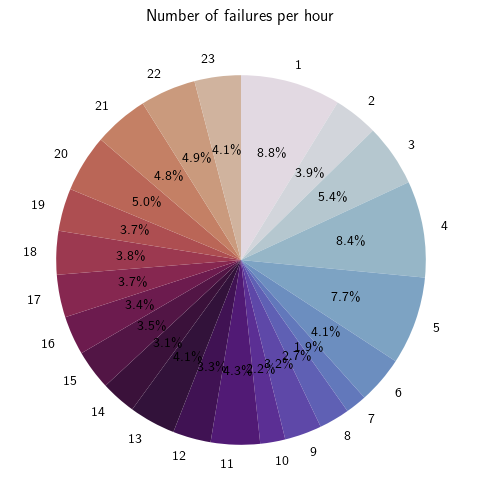

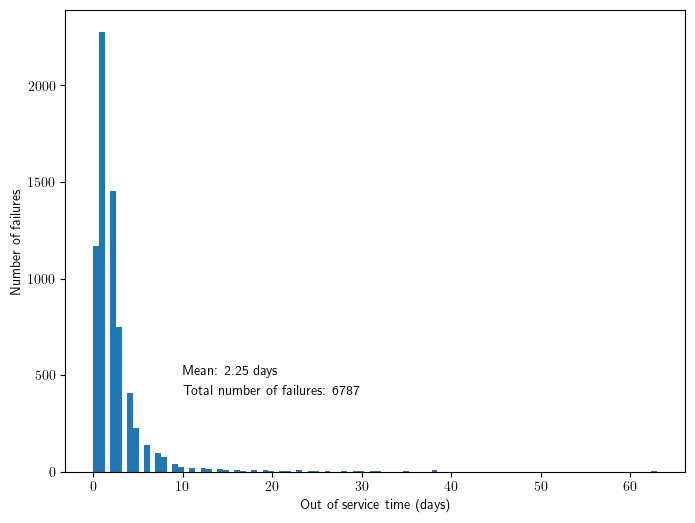

percentage of failures with out of service time > 10 days: 1.930160601149256

Causegroup
cabin    2.154472
cable    2.759633
joint    2.228139
other    1.203166
Name: outofservice, dtype: float64


C:\Users\jil.etienne\AppData\Local\Temp\ipykernel_29184\3167632110.py:66: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(guasti_2012_2024_nodate.groupby('Causegroup')['outofservice'].mean())


In [13]:
some_stats_failures(guasti_2012_2024)


### obs brera

In [10]:
def get_hist_var(fname, varname):

    # Load the dataset
    dataset = pd.read_csv(fname)

    # Convert the 'Data-Ora' column to datetime and change name to VALID_DATE
    dataset['Data-Ora'] = pd.to_datetime(dataset['Data-Ora'])
    dataset['Data-Ora'] = (dataset['Data-Ora'] - dt.timedelta(hours=1)).dt.tz_localize('UTC')
    dataset.rename(columns={'Data-Ora':'VALID_DATE', ' Medio':varname}, inplace=True)

    # replace -999.0 with np.nan
    dataset[varname] = dataset[varname].replace(-999.0, np.nan)

    return dataset[['VALID_DATE', varname]]

temp_brera = get_hist_var(r'brera_station\brera_temp_2012_2023_subhourly.csv', varname='T')
print(temp_brera.head())

                 VALID_DATE   T
0 2011-12-31 23:00:00+00:00 NaN
1 2012-01-01 00:00:00+00:00 NaN
2 2012-01-01 01:00:00+00:00 NaN
3 2012-01-01 02:00:00+00:00 NaN
4 2012-01-01 03:00:00+00:00 NaN


In [11]:
RH_brera = get_hist_var(r'brera_station\brera_rh_2012_2023_subhourly.csv', varname='RH')
print(RH_brera.head())

                 VALID_DATE  RH
0 2011-12-31 23:00:00+00:00 NaN
1 2012-01-01 00:00:00+00:00 NaN
2 2012-01-01 01:00:00+00:00 NaN
3 2012-01-01 02:00:00+00:00 NaN
4 2012-01-01 03:00:00+00:00 NaN


### forecasts

In [12]:
var='T_2M_C'
dates_summer_2023 = [f'2023-{m}-{str(d).zfill(2)}T{str(h).zfill(2)}:00:00' for h in range(0, 24, 1) for m in range(6, 9, 1) for d in range(1, monthrange(2023, m)[1]+1, 1)]
forecast_summer = ds.DatasetBuilder().build(var=var, list_forecast_date=dates_summer_2023)

KeyboardInterrupt: 

## Plot

In [10]:
def plot_all_guasti(guasti, hist_temp, load):
    """
    Plot the number of failures per month, stacked bar plot with one color per cause

    hist_temp: DataFrame, the historical temperature data in Brera daily temp
    """

    # Group by month and cause
    guasti['YearMonth'] = guasti['Data di guasto'].dt.to_period('M')
    guasti_monthly = guasti.groupby(['YearMonth', 'Causegroup']).size().unstack()

    # Plot the stacked bar plot
    fig, ax = plt.subplots(figsize=(12, 8))

    colors = {'cable': 'blue', 'cabin': 'orange', 'other': '#2ca02c', 'joint': 'red'}
    
    guasti_monthly.plot(kind='bar', stacked=True, color=colors, ax=ax)

    # temperature yaxis, compute mean max and min for the month
    #hist_temp['YearMonth'] = hist_temp['VALID_DATE'].dt.to_period('M')
    #hist_temp_monthly = hist_temp.groupby('YearMonth')['VALUE'].agg(['mean', 'max', 'min'])
    
    # plot temperature on the second y-axis
    #ax2 = ax.twinx()
    #ax2.plot(hist_temp_monthly.index.astype(str), hist_temp_monthly['mean'], color='grey', label='Temperature')
    #ax2.fill_between(hist_temp_monthly.index.astype(str), hist_temp_monthly['min'], hist_temp_monthly['max'], color='grey', alpha=0.2)
    #ax2.set_ylabel('Tmemperature (°C)')
    #ax2.set_ylim(-5, hist_temp_monthly['max'].max() + 15)

    # load yaxis
    #load['YearMonth'] = load['VALID_DATE'].dt.to_period('M')
    #load_monthly = load.groupby('YearMonth')['LOAD'].mean()

    # plot load on the second y-axis
    #ax3 = ax.twinx()
    #ax3.spines['right'].set_position(('outward', 60))
    #ax3.plot(load_monthly.index.astype(str), load_monthly, color='black', label='Load')
    #ax3.set_ylabel('Load (MWh)')
    #ax3.set_ylim(0, load_monthly.max() + 1000)

    # major ticks every 6 months
    ax.xaxis.set_major_locator(MultipleLocator(6))
    ax.xaxis.set_minor_locator(MultipleLocator(1))


    ax.set_xlabel('Month')
    ax.set_ylabel('Number of failures')
    ax.set_title('Number of failures per month by cause')

    ax.legend(title='Cause',ncols=4)
    plt.show()

    # print the number of failures per cause
    print(guasti['Causegroup'].value_counts())

    # number of failures but only for summer months
    summer_months = [6, 7, 8]
    guasti_summer = guasti[guasti['Data di guasto'].dt.month.isin(summer_months)]
    print(guasti_summer['Causegroup'].value_counts())

    # days with the most failures
    print(guasti['Data di guasto'].dt.date.value_counts().head(10))

    # average number of failures per month over the years
    print(guasti_monthly.mean())


    return None

In [11]:
plot_all_guasti(guasti_2012_2024, temp_brera, load_summer_2023)

NameError: name 'temp_brera' is not defined

In [12]:
def plot_failures_against_temp(dataset_input_failures, dataset_temp, dataset_RH):
    """
    Plot the number of failures per day against the mean, min and max temperature in Brera

    dataset_failures: DataFrame, the dataset of failures
    dataset_temp: DataFrame, the dataset of hourly temperature in Brera with columns 'VALID_DATE', 'T'
    dataset_RH: DataFrame, the dataset of hourly relative humidity in Brera with columns 'VALID_DATE', 'RH'
    """

    dataset_failures=dataset_input_failures.copy()

    # Group failures by day
    dataset_failures['Day'] = dataset_failures['Data di guasto'].dt.date
    dataset_failures_daily = dataset_failures.groupby('Day').size()
    dataset_failures_daily = dataset_failures_daily.reset_index(name='Nfailures')

    # change valid_date to Day rename columns withe the variable in weather variables
    dataset_temp['Day'] = dataset_temp['VALID_DATE'].dt.date
    dataset_RH['Day'] = dataset_RH['VALID_DATE'].dt.date

    # group by day and compute mean, min and max of columns T and RH
    dataset_temp = dataset_temp.groupby('Day').agg({'T':['mean','min','max']}).reset_index()
    dataset_RH = dataset_RH.groupby('Day').agg({'RH':['mean','min','max']}).reset_index()
    dataset_temp.columns = ['Day', 'Tmean', 'Tmin', 'Tmax']
    dataset_RH.columns = ['Day', 'RHmean', 'RHmin', 'RHmax']

    # Merge the three datasets
    dataset_daily = dataset_temp.merge(dataset_failures_daily, on='Day', how='left')
    dataset_daily = dataset_daily.merge(dataset_RH, on='Day', how='left')

    # Plot the number of failures per day against the mean, min and max temperature in mosaic plot
    fig, ax = plt.subplot_mosaic([['A', 'B'], ['C', 'D']], figsize=(8, 8))

    # ---------------- A ----------------

    # plot min and max against mean temperature
    ax['A'].scatter(dataset_daily['Tmean'], dataset_daily['Tmin'], color='cornflowerblue', s=1, alpha=0.3)
    ax['A'].scatter(dataset_daily['Tmean'], dataset_daily['Tmax'], color='tomato', s=1, alpha=0.3)
    ax['A'].scatter(dataset_daily['Tmean'], dataset_daily['Tmax']-dataset_daily['Tmin'], color='limegreen', s=1, alpha=0.3)

    # x=y
    ax['A'].plot([-5, 40], [-5, 40], color='grey', linestyle='--', linewidth=1)   

    # mask nan and fit linear
    mask = ~np.isnan(dataset_daily['Tmean']) & ~np.isnan(dataset_daily['Tmin']) & ~np.isnan(dataset_daily['Tmax'])
    slope, intercept, r_value, p_value, std_err = linregress(dataset_daily['Tmean'][mask], dataset_daily['Tmin'][mask])
    ax['A'].plot(dataset_daily['Tmean'][mask], slope*dataset_daily['Tmean'][mask] + intercept, color='blue', label=f'R2 Min {r_value**2:.2f}')
    slope, intercept, r_value, p_value, std_err = linregress(dataset_daily['Tmean'][mask], dataset_daily['Tmax'][mask])
    ax['A'].plot(dataset_daily['Tmean'][mask], slope*dataset_daily['Tmean'][mask] + intercept, color='red', label=f'R2 Max {r_value**2:.2f}')
    slope, intercept, r_value, p_value, std_err = linregress(dataset_daily['Tmean'][mask], dataset_daily['Tmax'][mask]-dataset_daily['Tmin'][mask])
    ax['A'].plot(dataset_daily['Tmean'][mask], slope*dataset_daily['Tmean'][mask] + intercept, color='green', label=f'R2 Range {r_value**2:.2f}')
    
    ax['A'].set_title('Temperatures correlation')
    ax['A'].set_xlabel('Mean temperature (°C)')
    ax['A'].set_ylabel('Temperature (°C)')
    ax['A'].legend()

    # ---------------- B ----------------

    # RH
    ax['B'].scatter(dataset_daily['RHmean'], dataset_daily['RHmin'], color='cornflowerblue', s=1, alpha=0.3, label='Min')
    ax['B'].scatter(dataset_daily['RHmean'], dataset_daily['RHmax'], color='tomato', s=1, alpha=0.3, label='Max')
    ax['B'].scatter(dataset_daily['RHmean'], dataset_daily['RHmax']-dataset_daily['RHmin'], color='limegreen', s=1, alpha=0.3, label='Range')

    # x=y
    ax['B'].plot([10, 100], [10, 100], color='grey', linestyle='--', linewidth=1)


    ax['B'].set_title('Relative Humidity correlation')
    ax['B'].set_xlabel(r'Mean RH (\%)')
    ax['B'].set_ylabel(r'RH (\%)')
    ax['B'].legend()

    # ---------------- C ----------------

    # bin by 5deg Tmean
    # compute the number of failures per bin and the number of days per bin
    bins = np.arange(-5, 40, 5)
    dataset_daily['Tmean_bin'] = pd.cut(dataset_daily['Tmean'], bins, right=False, ordered=True)
    dataset_daily['Nfailures'] = dataset_daily['Nfailures'].astype(float)

    # replace all Pfailures with 0 if Nfailures is nan, and with 1 if >=1
    dataset_daily['Nfailures'] = dataset_daily['Nfailures'].fillna(0)
    dataset_daily['Nfailures1'] = dataset_daily['Nfailures'].apply(lambda x: 1 if x >= 1 else 0)
    dataset_daily['Nfailures5'] = dataset_daily['Nfailures'].apply(lambda x: 1 if x >= 5 else 0)

    dataset_daily = dataset_daily.groupby('Tmean_bin').agg({'Nfailures1':'sum', 'Nfailures5':'sum', 'Day':'count'}).reset_index()
    
    # Pfailures is the proportion of days with failures per bin, compare to the number of days in the bin
    dataset_daily['Pfailures1'] = dataset_daily['Nfailures1']/dataset_daily['Day']
    dataset_daily['Pfailures5'] = dataset_daily['Nfailures5']/dataset_daily['Day']

    # change type to str
    dataset_daily['Tmean_bin'] = dataset_daily['Tmean_bin'].astype(str)
        
    ax['C'].bar(dataset_daily['Tmean_bin'], dataset_daily['Pfailures1'], color='cornflowerblue', align='edge', width=0.8)
    ax['C'].bar(dataset_daily['Tmean_bin'], dataset_daily['Pfailures5'], color='tomato', align='edge', width=0.8, alpha=0.5)
    
    ax['C'].set_ylim(0,0.9)
    ax['C'].tick_params(axis='x', rotation=45)
    ax['C'].set_title('Proportions of days with failures\nper mean temperature bin')
    ax['C'].set_xlabel('Mean temperature bin (°C)')
    ax['C'].set_ylabel('Proportions of days with failures')

    ax['C'].legend([r'$\ge$ 1 failure', r'$\ge$ 5 failures'])

    # ---------------- D ----------------

    # geroup and count number of failures per branch
    failure_by_branch = dataset_input_failures.copy()
    # summer days
    #failure_by_branch = failure_by_branch[(failure_by_branch['Data di guasto'].dt.month >= 6) & (failure_by_branch['Data di guasto'].dt.month <= 8)]
    # joints only
    #failure_by_branch = failure_by_branch[failure_by_branch['Causegroup'] == 'joint']
    # between 2015 and 2019 only
    #failure_by_branch = failure_by_branch[(failure_by_branch['Data di guasto'].dt.year >= 2015) & (failure_by_branch['Data di guasto'].dt.year <= 2019)]

    failure_by_branch['Branch'] = failure_by_branch['da cabina'] + ' - ' + failure_by_branch['a cabina']
    failure_by_branch['Nfailures'] = 1
    failure_by_branch = failure_by_branch.groupby('Branch').agg({'Nfailures':'sum'}).reset_index()
    failure_by_branch = failure_by_branch[~failure_by_branch['Branch'].str.contains('nan')]
    failure_by_branch = failure_by_branch.sort_values(by='Nfailures', ascending=True)
    failure_by_branch = failure_by_branch.reset_index(drop=True)
    failure_by_branch['cumulative'] = failure_by_branch['Nfailures'].cumsum()

    # plot the number of failures per branch
    ax['D'].plot(failure_by_branch['cumulative'], color='tomato', linestyle='-', linewidth=1)
    ax['D'].set_title('Number of failures per branch')

    ax['D'].set_xlabel('Branch ordered by number of failures')
    ax['D'].set_ylabel('Cumulative number of failures')
    
    # ADD vertical space between plots
    fig.subplots_adjust(hspace=0.4)


    return None

C:\Users\jil.etienne\AppData\Local\Temp\ipykernel_11292\4229046065.py:87: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dataset_daily = dataset_daily.groupby('Tmean_bin').agg({'Nfailures1':'sum', 'Nfailures5':'sum', 'Day':'count'}).reset_index()


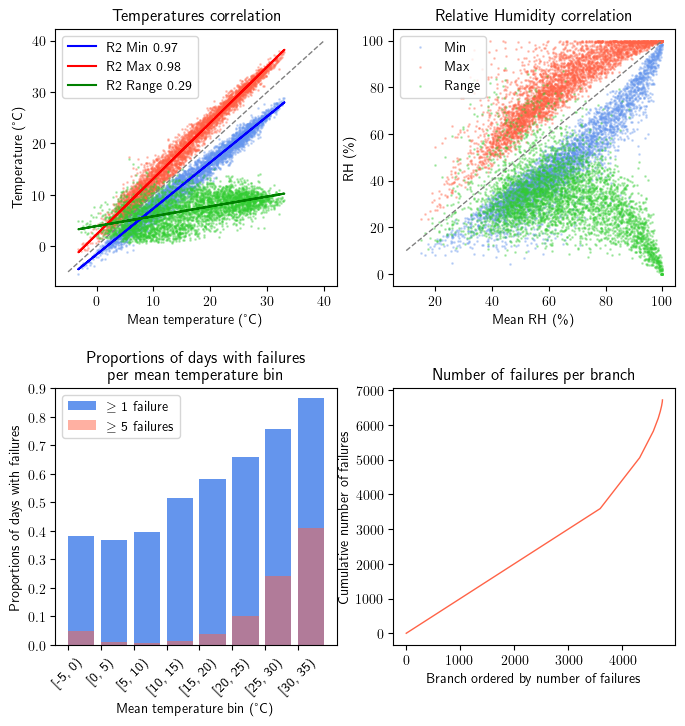

In [76]:
plot_failures_against_temp(guasti_2012_2024, temp_brera, RH_brera)

In [ ]:
def cooling_degree_day(dataset_temp, threshold):
    """
    compute the monthly cooling degree days for a dataset of temperature.
    cooling degree days are computed as the sum of the difference between the daily temperature and the reference temperature (T0=21°C) for each day of the month, if the daily mean temperature is above the threshold.


    dataset_temp: DataFrame, the temperature dataset
    threshold: float, the temperature threshold to consider

    Returns:
    - cdd: DataFrame, the monthly cooling degree days
    """
    T0=21
    
    # group by day and compute mean, min and max of columns T 
    dataset_temp = dataset_temp.groupby('Day').agg({'T':['mean','min','max']}).reset_index()
    dataset_temp.columns = ['Day', 'Tmean', 'Tmin', 'Tmax']

    # day to datetime
    dataset_temp['Day'] = pd.to_datetime(dataset_temp['Day'], format='%Y-%m-%d', errors='coerce')

    # Group by month and compute the sum of the difference between the daily temperature and the reference temperature
    dataset_temp['YearMonth'] = dataset_temp['Day'].dt.to_period('M')

    # compute CDD, filling missing values with previous values (to still compute the CDD for the month)
    dataset_temp['Tmean'] = dataset_temp['Tmean'].fillna(method='ffill')
    dataset_temp['Tmean'] = dataset_temp['Tmean'].astype(float)

    dataset_temp['CDD'] = dataset_temp.apply(lambda row: row['Tmean'] - T0 if row['Tmean'] > threshold else 0, axis=1)
    cdd = dataset_temp.groupby('YearMonth')['CDD'].sum().reset_index()

    # set the index to the month
    cdd.set_index('YearMonth', inplace=True)

    return cdd
    

In [93]:
cdd_brera = cooling_degree_day(temp_brera, 24)
print(cdd_brera)

                  CDD
YearMonth            
2011-12      0.000000
2012-01      0.000000
2012-02      0.000000
2012-03      0.000000
2012-04      0.000000
...               ...
2023-08    174.566667
2023-09     46.008333
2023-10      0.000000
2023-11      0.000000
2023-12      0.000000

[145 rows x 1 columns]


C:\Users\jil.etienne\AppData\Local\Temp\ipykernel_11292\3123179174.py:26: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  dataset_temp['Tmean'] = dataset_temp['Tmean'].fillna(method='ffill')


In [94]:
def plot_guasti_against_cdd(dataset_guasti, dataset_cdd, threshold, causeG):
    """
    Plot the number of failures per month (y axis) against the monthly cooling degree days (x axis) as a scatter plot.
    
    dataset_guasti: DataFrame, the dataset of failures
    dataset_cdd: DataFrame, the dataset of cooling degree days
    """

    colors = {'cable': 'blue', 'cabin': 'orange', 'other': '#2ca02c', 'joint': 'red'}
    markers= {6: 'o', 7: 's', 8: '^', 1: 'x', 2:'x', 3:'x', 4:'x', 5:'x', 9:'x', 10:'x', 11:'x', 12:'x'}

    if causeG:
        # count the number of failures per month and cause
        dataset_guasti['YearMonth'] = dataset_guasti['Data di guasto'].dt.to_period('M')
        guasti_monthly = dataset_guasti.groupby(['YearMonth', 'Causegroup']).size().unstack()

        # reset the index
        guasti_monthly.reset_index(inplace=True)
        
        # merge with the cdd dataset
        guasti_monthly = guasti_monthly.merge(dataset_cdd[:-1], how='left', on='YearMonth')

        # Plot the scatter plot
        # different markers for different months
        # different colors for different causes
        fig, ax = plt.subplots(figsize=(6, 6))
        for cause in colors.keys():
            for month in range(1, 13):
                subdataset = guasti_monthly[guasti_monthly['YearMonth'].dt.month == month]
                ax.scatter(subdataset['CDD'], subdataset[cause], label=cause, color=colors[cause], marker=markers[month])

        # iterate over Yearmonth
        # for a count of failure higher than 120, print the YearMonth on the scatter plot
        for i, row in guasti_monthly.iterrows():
            for cause in colors.keys():
                if row[cause] > 93:
                    ax.text(row['CDD'], row[cause], row['YearMonth'], fontsize=8)
                
        
        ax.set_xlabel(f'Cooling Degree Days (threshold={threshold}°C)')
        ax.set_ylabel('Monthly number of failures')
        ax.set_title('Monthly number of failures per month against the\nmonthly Cooling Degree Days')

        # custom legend
        handles, labels = ax.get_legend_handles_labels()
        unique_labels = list(set(labels))
        unique_handles = [handles[labels.index(label)] for label in unique_labels]

        # add the amrkers to the legend
        unique_handles = unique_handles + [Line2D([0], [0], marker=markers[month], color='w', label=f'Month {month}', markerfacecolor='black', markersize=10) for month in range(6, 9)]
        unique_labels = unique_labels + [f'Month {month}' for month in range(6, 9)]
        
        ax.legend(unique_handles, unique_labels, title='Cause')
        
        plt.show()  
        plt.close()

    return None


C:\Users\jil.etienne\AppData\Local\Temp\ipykernel_11292\227401956.py:14: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  dataset_guasti['YearMonth'] = dataset_guasti['Data di guasto'].dt.to_period('M')
C:\Users\jil.etienne\AppData\Local\Temp\ipykernel_11292\227401956.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  guasti_monthly = dataset_guasti.groupby(['YearMonth', 'Causegroup']).size().unstack()


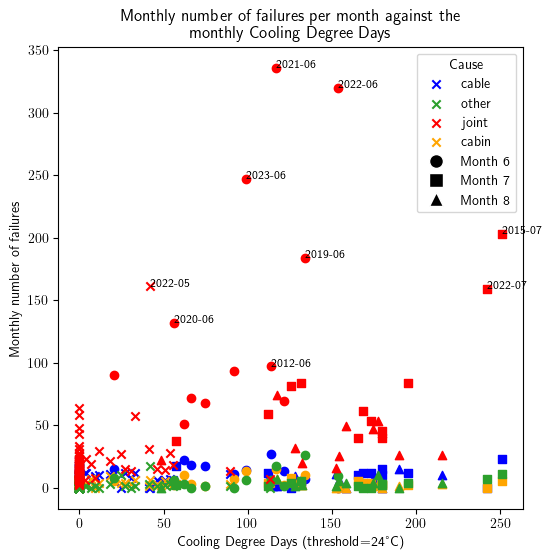

In [95]:
plot_guasti_against_cdd(guasti_2012_2024, cdd_brera, threshold=24, causeG=True)


In [96]:
guasti_summer_2023=get_guasti('pri_raw_pri_2023-12-11.xlsx', dstart=dt.date(2023, 6, 1), dend=dt.date(2023, 8, 31))

In [97]:
def cross_correlation(dataset1, dataset2, var1, var2, lags):
    """
    Compute the cross-correlation between two time series

    dataset1: DataFrame, the first dataset
    dataset2: DataFrame, the second dataset
    var1: str, the name of the first variable
    var2: str, the name of the second variable
    lags: list, the list of lags to consider

    Returns:
    - corr : DataFrame, with columns corr_pearson, corr_spearman
    """

    # merge the two datasets on the date
    merged = dataset1.merge(dataset2, on='VALID_DATE', how='inner')


    # compute the cross-correlation for each lag
    corrs_p = [merged[var1].corr(merged[var2].shift(lag)) for lag in lags]
    corrs_s = [merged[var1].rank().corr(merged[var2].rank().shift(lag)) for lag in lags]

    # create the DataFrame, index named lags
    corr = pd.DataFrame({'corr_pearson': corrs_p, 'corr_spearman': corrs_s}, index=lags)
    corr.index.name = 'lag'

    return corr

In [121]:
def plot_cross_correlation(dataset_load, dataset_temp, dataset_RH, lags, names):
    """
    Plot the ranked cross-correlation between two time series

    dataset_load: DataFrame, the dataset of the first time series
    dataset_temp: DataFrame, the dataset of the second time series
    dataset_RH: DataFrame, the dataset of the third time series
    lags: list, the lags to consider
    names: list, the names of the two time series
    """

     # group by day and compute mean, min and max of columns T 
    dataset_temp = dataset_temp.groupby('Day').agg({'T':['mean','min','max']}).reset_index()
    dataset_temp.columns = ['VALID_DATE', 'Tmean', 'Tmin', 'Tmax']
    dataset_RH = dataset_RH.groupby('Day').agg({'RH':['mean','min','max']}).reset_index()
    dataset_RH.columns = ['VALID_DATE', 'RHmean', 'RHmin', 'RHmax']
    dataset_load = dataset_load.groupby('VALID_DATE').agg({'LOAD':['mean','min','max']}).reset_index()
    dataset_load.columns = ['VALID_DATE', 'LOADmean', 'LOADmin', 'LOADmax']

    # day to datetime
    dataset_temp['VALID_DATE'] = pd.to_datetime(dataset_temp['VALID_DATE'], format='%Y-%m-%d', errors='coerce').dt.tz_localize('UTC')
    dataset_RH['VALID_DATE'] = pd.to_datetime(dataset_RH['VALID_DATE'], format='%Y-%m-%d', errors='coerce').dt.tz_localize('UTC')
    dataset_load['VALID_DATE'] = pd.to_datetime(dataset_load['VALID_DATE'], format='%Y-%m-%d', errors='coerce')

    # Compute the cross-correlation for each lag, per day
    cross1 = cross_correlation(dataset_load, dataset_temp,'LOADmean', 'Tmean', lags)
    cross2 = cross_correlation(dataset_load, dataset_RH, 'LOADmean', 'RHmean', lags)

    # Plot the ranked cross-correlation
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(cross1.index, cross1['corr_pearson'], linestyle='-', color='r', label=f'Pearson {names[0]} - {names[1]}')
    ax.plot(cross2.index, cross2['corr_pearson'], linestyle='-', color='b', label=f'Pearson {names[0]} - {names[2]}')
    ax.plot(cross1.index, cross1['corr_spearman'], linestyle='--', color='r', label=f'Spearman {names[0]} - {names[1]}')
    ax.plot(cross2.index, cross2['corr_spearman'], linestyle='--', color='b', label=f'Spearman {names[0]} - {names[2]}')
    ax.axhline(0, color='black', linewidth=1)
    ax.set_xlabel('lag (days)')
    ax.set_ylabel('Cross-correlation')
    ax.set_ylim(-1., 1.)
    ax.set_title('Pearson and Spearman Cross-correlations')
    ax.grid(True)

    ax.legend(ncols=2)
    plt.show()

    return None



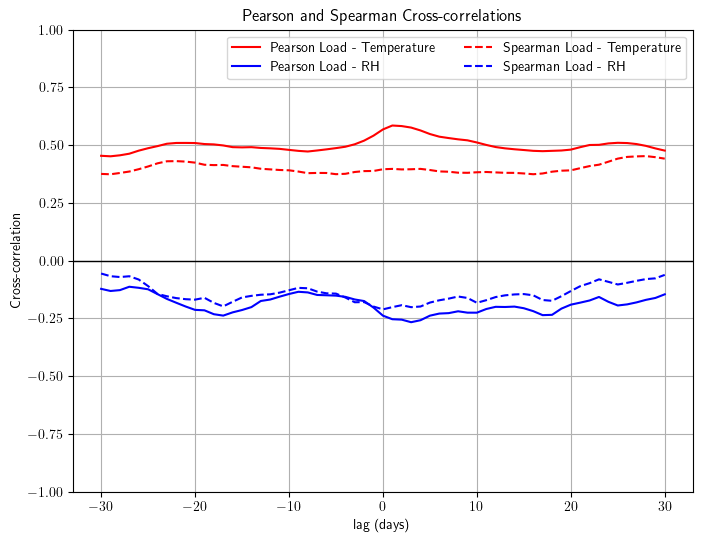

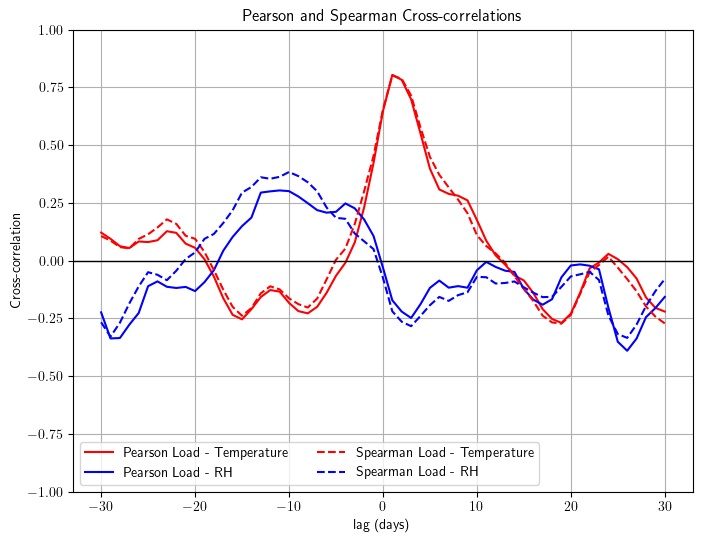

"\n# only for june\ntemp_brera_june = temp_brera[(temp_brera['VALID_DATE'].dt.month == 6)]\nRH_brera_june = RH_brera[(RH_brera['VALID_DATE'].dt.month == 6)]\nload_2023_june = load_2023[(load_2023['VALID_DATE'].dt.month == 6)]\nplot_ranked_cross_correlation(load_2023_june, temp_brera_june, RH_brera_june, 'LOAD', 'VALUE', lags, names=['Load', 'Temperature', 'RH'])\n\n# july\ntemp_brera_july = temp_brera[(temp_brera['VALID_DATE'].dt.month == 7)]\nRH_brera_july = RH_brera[(RH_brera['VALID_DATE'].dt.month == 7)]\nload_2023_july = load_2023[(load_2023['VALID_DATE'].dt.month == 7)]\nplot_ranked_cross_correlation(load_2023_july, temp_brera_july, RH_brera_july, 'LOAD', 'VALUE', lags, names=['Load', 'Temperature', 'RH'])\n\n# august\ntemp_brera_august = temp_brera[(temp_brera['VALID_DATE'].dt.month == 8)]\nRH_brera_august = RH_brera[(RH_brera['VALID_DATE'].dt.month == 8)]\nload_2023_august = load_2023[(load_2023['VALID_DATE'].dt.month == 8)]\nplot_ranked_cross_correlation(load_2023_august, temp_

In [122]:
lags = range(-30, 31)
plot_cross_correlation(load_2023, temp_brera, RH_brera, lags, names=['Load', 'Temperature', 'RH'])

# only for summer
temp_brera_summer = temp_brera[(temp_brera['VALID_DATE'].dt.date >= dt.date(2023, 6, 1)) & (temp_brera['VALID_DATE'].dt.date <= dt.date(2023, 8, 31))]
RH_brera_summer = RH_brera[(RH_brera['VALID_DATE'].dt.date >= dt.date(2023, 6, 1)) & (RH_brera['VALID_DATE'].dt.date <= dt.date(2023, 8, 31))]
plot_cross_correlation(load_summer_2023, temp_brera_summer, RH_brera_summer, lags, names=['Load', 'Temperature', 'RH'])

"""
# only for june
temp_brera_june = temp_brera[(temp_brera['VALID_DATE'].dt.month == 6)]
RH_brera_june = RH_brera[(RH_brera['VALID_DATE'].dt.month == 6)]
load_2023_june = load_2023[(load_2023['VALID_DATE'].dt.month == 6)]
plot_ranked_cross_correlation(load_2023_june, temp_brera_june, RH_brera_june, 'LOAD', 'VALUE', lags, names=['Load', 'Temperature', 'RH'])

# july
temp_brera_july = temp_brera[(temp_brera['VALID_DATE'].dt.month == 7)]
RH_brera_july = RH_brera[(RH_brera['VALID_DATE'].dt.month == 7)]
load_2023_july = load_2023[(load_2023['VALID_DATE'].dt.month == 7)]
plot_ranked_cross_correlation(load_2023_july, temp_brera_july, RH_brera_july, 'LOAD', 'VALUE', lags, names=['Load', 'Temperature', 'RH'])

# august
temp_brera_august = temp_brera[(temp_brera['VALID_DATE'].dt.month == 8)]
RH_brera_august = RH_brera[(RH_brera['VALID_DATE'].dt.month == 8)]
load_2023_august = load_2023[(load_2023['VALID_DATE'].dt.month == 8)]
plot_ranked_cross_correlation(load_2023_august, temp_brera_august, RH_brera_august, 'LOAD', 'VALUE', lags, names=['Load', 'Temperature', 'RH'])
"""

In [123]:
def plot_timeseries_load_temp(dataset_load, dataset_temp, dataset_rh, guasti, name):
    """
    Plot the timeseries of load and temperatures in degrees C

    Parameters:
    dataset_load: the dataset containing the load values
    dataset_temp: the dataset containing the temperature values
    name: the string used as name complement for the plot

    Returns:
    None
    """

    # ---------------- TIMESERIES AVERAGED OVER THE STATIONS

    fig, ax = plt.subplots(2,1, figsize=(14, 7), sharex=True)

    # Plot the load timeseries
    ax[0].plot(dataset_load['VALID_DATE'], dataset_load['LOAD'], color='k', linewidth=1, linestyle='--')
    ax[0].set_ylim([-1000, dataset_load['LOAD'].max() + 1000])
    ax[0].set_yticks(np.arange(0, dataset_load['LOAD'].max() + 100, 400))
    ax[0].set_ylabel('Load (MWh)', color='k')
    ax[0].tick_params(axis='y', labelcolor='k')
    ax[0].grid(True)
    plt.margins(x=0)

    # Create a second and 3rd y-axis for temperature, color green
    ax2 = ax[0].twinx()
    ax3 = ax[0].twinx()

    # observations T_2M_C
    obs_data = dataset_temp[['OBSERVATION_T_2M_C', 'VALID_DATE', 'LAT_STATION', 'LON_STATION']].dropna() 
    obs_data = obs_data[obs_data['VALID_DATE'].dt.date.isin(dataset_load['VALID_DATE'].dt.date.unique())] # keep only the dates present in the load dataset
    obs_data = obs_data.drop_duplicates(subset=['VALID_DATE', 'LAT_STATION', 'LON_STATION']) # remove duplicates from different forecasts linked to the same station
    obs_data = obs_data.groupby('VALID_DATE')['OBSERVATION_T_2M_C'].mean().reset_index() # average over the stations

    # observation rh
    obs_data_rh = dataset_rh[['OBSERVATION_RH', 'VALID_DATE', 'LAT_STATION', 'LON_STATION']].dropna()
    obs_data_rh = obs_data_rh[obs_data_rh['VALID_DATE'].dt.date.isin(dataset_load['VALID_DATE'].dt.date.unique())] # keep only the dates present in the load dataset
    obs_data_rh = obs_data_rh.drop_duplicates(subset=['VALID_DATE', 'LAT_STATION', 'LON_STATION']) # remove duplicates from different forecasts linked to the same station
    obs_data_rh = obs_data_rh.groupby('VALID_DATE')['OBSERVATION_RH'].mean().reset_index() # average over the stations

    # merge the two datasets
    obs_data = obs_data.merge(obs_data_rh, on='VALID_DATE')

    # PLOT OBS
    ax2.plot(obs_data['VALID_DATE'], obs_data['OBSERVATION_T_2M_C'], color='r', linewidth=1, linestyle='--')
    ax3.plot(obs_data['VALID_DATE'], obs_data['OBSERVATION_RH'], color='b', linewidth=1, linestyle='--')

    ax2.set_ylabel('Temperature (°C)', color='r', loc='top')
    ax2.set_ylim(-40, obs_data['OBSERVATION_T_2M_C'].max() + 5)
    ax2.set_yticks(np.arange(10, obs_data['OBSERVATION_T_2M_C'].max() + 5, 5))
    ax2.tick_params(axis='y', labelcolor='r', color='r')
    ax2.grid(True)

    ax3.set_ylabel('RH (%)', color='b', loc='bottom')
    ax3.set_ylim(0, obs_data['OBSERVATION_RH'].max() + 150)
    ax3.set_yticks(np.arange(0, obs_data['OBSERVATION_RH'].max() + 10, 20))
    ax3.tick_params(axis='y', labelcolor='b')
    ax3.grid(True)

    # rolling mean 24h
    ax[0].plot(dataset_load['VALID_DATE'], dataset_load['LOAD'].rolling(window=24, center=True).mean(), color='k', linestyle='-', label='Rolling Mean Load')
    ax[0].set_ylabel('Load (MWh)', color='k')
    ax[0].tick_params(axis='y', labelcolor='k')

    ax2.plot(obs_data['VALID_DATE'], obs_data['OBSERVATION_T_2M_C'].rolling(window=24, center=True).mean(), color='r', linestyle='-', label='Rolling Mean Temperature')
    ax3.plot(obs_data['VALID_DATE'], obs_data['OBSERVATION_RH'].rolling(window=24, center=True).mean(), color='b', linestyle='-', label='Rolling Mean RH')
    
    # guasti stacked barplot per Causegroup
    colors = {'cable': 'blue', 'cabin': 'orange', 'other': '#2ca02c', 'joint': 'red'}
    guasti_causa = guasti.groupby(guasti['Data di guasto'].dt.date)['Causegroup'].value_counts().unstack().fillna(0).stack().reset_index(name='counts') # group by date and cause

    # add missing days to the dataset
    all_dates = pd.date_range(start=guasti_causa['Data di guasto'].min(), end=guasti_causa['Data di guasto'].max(), freq='D')
    all_causes = guasti_causa['Causegroup'].unique()
    all_combinations = pd.MultiIndex.from_product([all_dates, all_causes], names=['Data di guasto', 'Causegroup'])
    guasti_causa = guasti_causa.set_index(['Data di guasto', 'Causegroup']).reindex(all_combinations).reset_index()
    guasti_causa['counts'] = guasti_causa['counts'].fillna(0)
    
    guasti_causa = guasti_causa.pivot(index='Data di guasto', columns='Causegroup', values='counts').fillna(0)
    for i, col in enumerate(guasti_causa.columns):
        p=ax[1].bar(guasti_causa.index, guasti_causa[col], bottom=guasti_causa.iloc[:, :i].sum(axis=1), label=col, color=colors[col])
    ax[1].set_ylabel('Number of Failures')
    ax[1].set_ylim(0, guasti_causa.sum(axis=1).max()+1)  
    ax[1].legend(title='Cause of Failure', bbox_to_anchor=(-0.01, -0.4), loc='upper left', ncols=4)
    ax[1].grid(True)
    ax[1].set_xlabel('Date')

    fig.suptitle(f'Timeseries of Load and Temperature in {name}')
    plt.show()
    plt.close()

    
    # --------------- daily profile
    fig, ax = plt.subplots(1, 2, figsize=(14, 7))
    colors_load=['yellow', 'orange', 'red']
    colors_temp=['lightblue', 'skyblue', 'blue']

    # filter by month, group by time of the day and compute the mean
    for i, month in enumerate(range(6, 9)):
        dataset_load_month = dataset_load[dataset_load['VALID_DATE'].dt.month == month]
        daily_load = dataset_load.groupby(dataset_load_month['VALID_DATE'].dt.hour)['LOAD'].mean().reset_index()

        dataset_temp_month= dataset_temp[dataset_temp['VALID_DATE'].dt.month == month]
        daily_temp = dataset_temp_month.groupby(dataset_temp_month['VALID_DATE'].dt.hour)['OBSERVATION_T_2M_C'].mean().reset_index()
        
        # Plot the daily profile
        ax[0].plot(daily_load['LOAD'], color=colors_load[i], label=f'Load {month}')
        ax[1].plot(daily_temp['OBSERVATION_T_2M_C'], color=colors_temp[i], label=f'Temperature {month}')

    # plot a random day
    random_day = dataset_load[dataset_load['VALID_DATE'].dt.date == dt.date(2023, 6, 15)]
    daily_load = random_day.groupby(random_day['VALID_DATE'].dt.hour)['LOAD'].mean().reset_index()
    daily_temp = dataset_temp[dataset_temp['VALID_DATE'].dt.date == dt.date(2023, 6, 15)].groupby(dataset_temp['VALID_DATE'].dt.hour)['OBSERVATION_T_2M_C'].mean().reset_index()
    ax[0].plot(daily_load['LOAD'], color='black', label='Load Random Day')
    ax[1].plot(daily_temp['OBSERVATION_T_2M_C'], color='black', label='Temperature Random Day')

    ax[0].set_xlabel('Hour')
    ax[0].set_ylabel('Load (MWh)')
    ax[0].tick_params(axis='y')
    ax[0].legend()
    ax[0].grid(True)

    ax[1].set_xlabel('Hour')
    ax[1].set_ylabel('Temperature (°C)')
    ax[1].tick_params(axis='y')
    ax[1].legend()
    ax[1].grid(True)
    
    fig.suptitle(f'Daily Profile of Load and Temperature in {name}')
    plt.show()
    plt.close()
    
        
    return None

In [124]:
plot_timeseries_load_temp(load_summer_2023, dataset_T_2M_C_summer_2023, dataset_RH_summer_2023, guasti_summer_2023, name='JJA 2023')

NameError: name 'dataset_T_2M_C_summer_2023' is not defined

In [125]:
def temp_against_guasti(dataset_temp, dataset_load, guasti):
    """
    Plot the failures against the temperature registered at the time the failure happens (failure=guasto).
    Each month is on a different subplot.
    color is the type of failure
    """

    # manipulate the temperature dataset 
    obs_data = dataset_temp[['OBSERVATION_T_2M_C', 'VALID_DATE', 'LAT_STATION', 'LON_STATION']].dropna() 
    obs_data = obs_data.drop_duplicates(subset=['VALID_DATE', 'LAT_STATION', 'LON_STATION']) # remove duplicates from different forecasts linked to the same station
    obs_data = obs_data.groupby('VALID_DATE')['OBSERVATION_T_2M_C'].mean().reset_index() # average over the stations
    obs_data['VALID_DATE'] = pd.to_datetime(obs_data['VALID_DATE'])

    # manipulate the load dataset
    dataset_load['VALID_DATE'] = pd.to_datetime(dataset_load['VALID_DATE'])

    # plot the scatter plot
    fig, ax = plt.subplots(1, 1, figsize=(8,6), sharex=True, sharey=True)

    # replace nan in cause with NON ACCERTATA
    guasti['Causa accertata'] = guasti['Causa accertata'].fillna('NON ACCERTATA')

    # create a color map for the causes
    colors_guasti = plt.cm.get_cmap('tab20', len(guasti['Causa accertata'].unique()))(np.arange(len(guasti['Causa accertata'].unique())))
    colors_guasti = {cause: colors_guasti[i] for i, cause in enumerate(sorted(guasti['Causa accertata'].unique()))}

    marker_month = ['o', '^', 's']

    # for each month
    for i, month in enumerate(range(6, 9)):
        guasti_month = guasti[guasti['Data di guasto'].dt.month == month]
        obs_data_month = obs_data[obs_data['VALID_DATE'].dt.month == month]
        obs_data_month = obs_data_month.set_index('VALID_DATE') # set the index to the date

        # order the guasti by date
        guasti_month = guasti_month.sort_values('Data di guasto')

        # for each guasto in the month, find the temperature at the day and preceeding hour of the failure
        list_day_hour = []
        mask = []
        for date in guasti_month['Data di guasto']:
            if date.hour == 0 and date.minute == 0 and date.second == 0: # default hour is 0
                mask.append(False) # to recognize the day
            else: # hour is accurate
                mask.append(True)
            list_day_hour.append(dt.datetime(date.year, date.month, date.day, date.hour, date.minute, date.second))

        # add timezone Europe/Rome
        list_day_hour = [date.replace(tzinfo=pytz.timezone('Europe/Rome')) for date in list_day_hour]

        list_temperatures = []
        list_loads = []
        for date in list_day_hour: # find closest date
            if mask: # take the temperature at that hour
                list_timedelta = [d-date if date <= d else date-d for d in obs_data_month.index]
                closest_date = obs_data_month.iloc[(np.argsort(list_timedelta))[:1]].index.values[0] # numpy.datetime64
                closest_date = pd.to_datetime(closest_date)
                closest_date = closest_date.tz_localize('UTC')
                list_temperatures.append(obs_data_month.loc[closest_date]['OBSERVATION_T_2M_C'])
                list_loads.append(dataset_load[dataset_load['VALID_DATE'].dt.date == date.date()]['LOAD'].values[0])

            else: # take temp avearge of the day
                obs_that_day = obs_data_month[(obs_data_month.index.year == date.year)&(obs_data_month.index.month == date.month)&(obs_data_month.index.day == date.day)]
                list_temperatures.append(np.mean(obs_that_day['OBSERVATION_T_2M_C']))

        # colors for causa
        c=[colors_guasti[cause] for cause in guasti_month['Causa accertata']]

        # plot the load y axis, x axis temperature, color is the cause
        ax.scatter(list_temperatures, list_loads, c=c, marker=marker_month[i])

        # circle if mask is true
        for j, mask in enumerate(mask):
            if mask:
                ax.scatter(list_temperatures[j], list_loads[j], facecolor='none', edgecolor='k', marker=marker_month[i])
        
        ax.set_ylabel('Load (MWh)')   

    ax.set_xlabel('Temperature (°C)')

    # legend
    patches = [mpatches.Patch(color=color, label=cause) for cause, color in colors_guasti.items()]+[Line2D([0], [0], linestyle='', markerfacecolor='none', markeredgecolor='k', marker=marker_month[i], label=f'Month {month}') for i, month in enumerate(range(6, 9))]
    ax.legend(handles=patches, bbox_to_anchor=(0.02, -0.2), loc='upper left', ncols=2)
    
    fig.suptitle('Failures in the temperature-load space')
    plt.show()
    plt.close()

    

In [ ]:
temp_against_guasti(dataset_T_2M_C_summer_2023, load_summer_2023,  guasti_summer_2023)

In [126]:
def plot_synop(day):
    """
    Plot the synop data for a given day, with 500hPa geopotential height, temperature and ground pressure.
    Data in .nc from era5.
    """

    # open .nc file
    GH = xr.open_dataset(r'data_era5\GH_500_summer_2023.nc') # one value per day
    T = xr.open_dataset(r'data_era5\t2m_summer_2023.nc')
    MLSP = xr.open_dataset(r'data_era5\MLSP_summer_2023.nc')

    # select the day
    GH_day = GH.sel(valid_time=day).sel(pressure_level=500)
    T_day = T.sel(valid_time=day)
    MLSP_day = MLSP.sel(valid_time=day)

    # plot the data on a map
    fig, ax = plt.subplots(1, 1, figsize=(10, 7), subplot_kw={'projection': ccrs.PlateCarree()})
    #ax.set_extent([5, 15, 44, 48], crs=ccrs.PlateCarree())

    # temperature as contourf plot
    c = ax.contourf(T_day['longitude'], T_day['latitude'], T_day['t2m'].values-273.15, cmap='coolwarm', vmin=0, vmax=40)
    fig.colorbar(c, ax=ax, label='2m Temperature (°C)', orientation='horizontal',aspect=100)
    ax.set_title(f'Temperature on {day}')

    # 500hPa geopotential height contours
    c = ax.contour(GH_day['longitude'], GH_day['latitude'], GH_day['z'].values, colors='k', linewirths=1, levels=np.arange(55000, 60000, 500))
    ax.clabel(c, fontsize=10)
    ax.set_title(f'500hPa Geopotential Height on {day}')

    # mean sea level pressure as contour plot
    c = ax.contour(MLSP_day['longitude'], MLSP_day['latitude'], MLSP_day['msl'].values/100, colors='b', linewidths=1, levels=np.arange(1013-30, 1013+30, 4))
    ax.clabel(c, fontsize=10)
    ax.set_title(f'{dt.datetime.strftime(day, "%Y-%m-%d")}')
    
    # plot country borders
    ax.add_feature(ctp.feature.BORDERS, linestyle=':', color='darkgrey')
    ax.add_feature(ctp.feature.COASTLINE, linewidth=0.5)

    return None

c:\Users\jil.etienne\AppData\Local\anaconda3\envs\dp\Lib\site-packages\cartopy\mpl\geoaxes.py:1600: UserWarning: The following kwargs were not used by contour: 'linewirths'
  result = super().contour(*args, **kwargs)
c:\Users\jil.etienne\AppData\Local\anaconda3\envs\dp\Lib\site-packages\cartopy\mpl\feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
c:\Users\jil.etienne\AppData\Local\anaconda3\envs\dp\Lib\site-packages\cartopy\mpl\geoaxes.py:1600: UserWarning: The following kwargs were not used by contour: 'linewirths'
  result = super().contour(*args, **kwargs)
c:\Users\jil.etienne\AppData\Local\anaconda3\envs\dp\Lib\site-packages\cartopy\mpl\feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


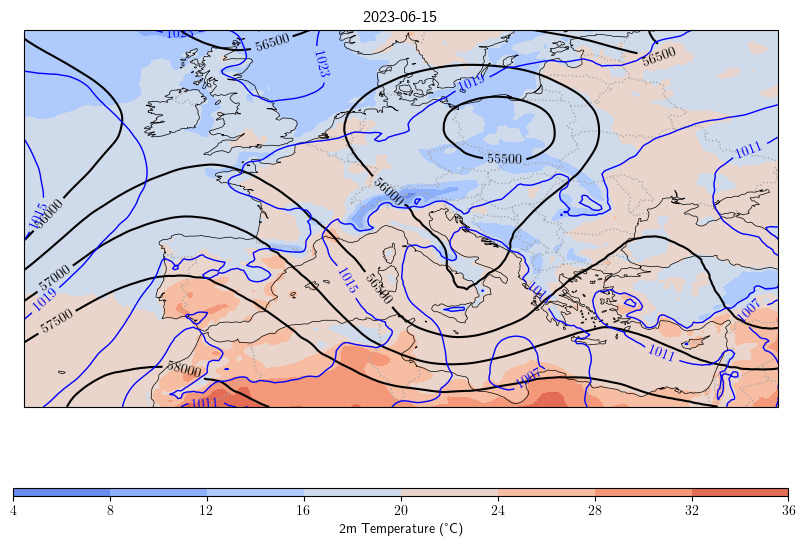

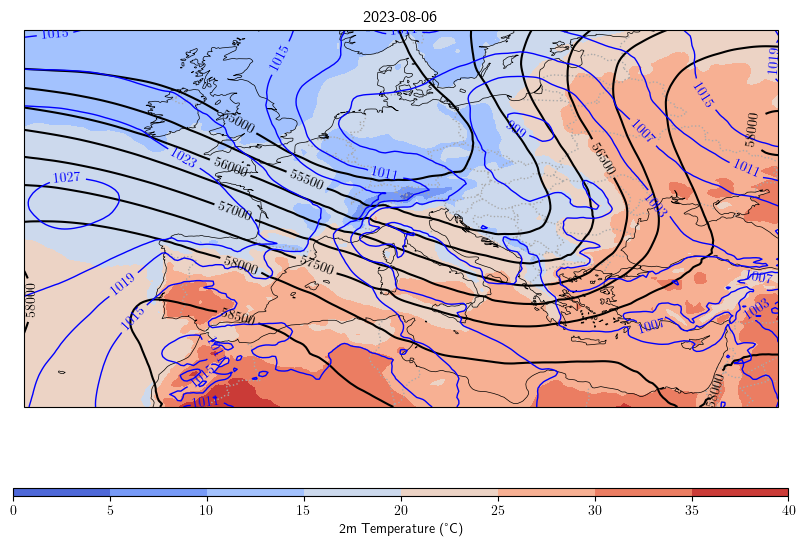

In [127]:
plot_synop(dt.datetime(2023, 6, 15))
plot_synop(dt.datetime(2023, 8, 6))


In [128]:
def power_spectral_density(dataset_load, dataset_temp, dataset_rh, name):
    """
    Plot the timeseries of load and temperatures in degrees C

    Parameters:
    dataset_load: the dataset containing the load values
    dataset_temp: the dataset containing the temperature values
    name: the string used as name complement for the plot

    Returns:
    None
    """

    # manipulate the temperature dataset 
    obs_data = dataset_temp[['OBSERVATION_T_2M_C', 'VALID_DATE', 'LAT_STATION', 'LON_STATION']].dropna() 
    obs_data = obs_data[obs_data['VALID_DATE'].dt.date.isin(dataset_load['VALID_DATE'].dt.date.unique())] # keep only the dates present in the load dataset
    obs_data = obs_data.drop_duplicates(subset=['VALID_DATE', 'LAT_STATION', 'LON_STATION']) # remove duplicates from different forecasts linked to the same station
    obs_data = obs_data.groupby('VALID_DATE')['OBSERVATION_T_2M_C'].mean().reset_index() # average over the stations

    # manipulate the humidity dataset
    obs_data_rh= dataset_rh[['OBSERVATION_RH', 'VALID_DATE', 'LAT_STATION', 'LON_STATION']].dropna()
    obs_data_rh = obs_data_rh[obs_data_rh['VALID_DATE'].dt.date.isin(dataset_load['VALID_DATE'].dt.date.unique())] # keep only the dates present in the load dataset
    obs_data_rh = obs_data_rh.drop_duplicates(subset=['VALID_DATE', 'LAT_STATION', 'LON_STATION']) # remove duplicates from different forecasts linked to the same station
    obs_data_rh = obs_data_rh.groupby('VALID_DATE')['OBSERVATION_RH'].mean().reset_index() # average over the stations
    
    # merge the datasets based on the date
    obs_data = obs_data.merge(obs_data_rh, on='VALID_DATE')

    # ------------- FOURIER TRANSFORM
    
    # load 
    load_size=len(dataset_load['LOAD'])
    #freq_load, load_psd = signal.welch(dataset_load['LOAD'], fs=1, nperseg=load_size, scaling='density')

    # load by hand
    load_psd = np.abs(np.fft.rfft(dataset_load['LOAD']))**2
    freq_load = np.fft.rfftfreq(len(dataset_load['LOAD']), d=1) # spectrum, in power/bin
    scaling_factor_load = 1/len(load_psd)*(np.nansum(freq_load)/np.nansum(freq_load**2)) # scaling density psd/spectrum psd
    load_psd = load_psd * scaling_factor_load # density in power/Hz
    #print('scaling factor:', scaling_factor) # 0.0027

    # temperature 
    temp_size=len(obs_data['OBSERVATION_T_2M_C'])
    temp_psd = np.abs(np.fft.rfft(obs_data['OBSERVATION_T_2M_C']))**2
    freq_temp = np.fft.rfftfreq(len(obs_data['OBSERVATION_T_2M_C']), d=1) # spectrum, in power/bin
    scaling_factor_temp = 1/len(temp_psd)*(np.nansum(freq_temp)/np.nansum(freq_temp**2)) # scaling density psd/spectrum psd
    temp_psd = temp_psd * scaling_factor_temp # density in power/Hz

    # humidity
    rh_size=len(obs_data['OBSERVATION_RH'])
    rh_psd = np.abs(np.fft.rfft(obs_data['OBSERVATION_RH']))**2
    freq_rh = np.fft.rfftfreq(len(obs_data['OBSERVATION_RH']), d=1) # spectrum, in power/bin
    scaling_factor_rh = 1/len(rh_psd)*(np.nansum(freq_rh)/np.nansum(freq_rh**2)) # scaling density psd/spectrum psd
    rh_psd = rh_psd * scaling_factor_rh # density in power/Hz

    # cross-spectral density (fourier transform of the cross-correlation of the two signals)
    load_temp_csd = signal.csd(dataset_load['LOAD'], obs_data['OBSERVATION_T_2M_C'], fs=1, nperseg=load_size, scaling='density')[1]
    load_rh_csd = signal.csd(dataset_load['LOAD'], obs_data['OBSERVATION_RH'], fs=1, nperseg=load_size, scaling='density')[1]

    # coherence
    freq_coh, load_temp_coherence = signal.coherence(dataset_load['LOAD'], obs_data['OBSERVATION_T_2M_C'], fs=1, nperseg=load_size/3)
    freq_coh, load_rh_coherence = signal.coherence(dataset_load['LOAD'], obs_data['OBSERVATION_RH'], fs=1, nperseg=load_size/3)

    # plot the PSD, load and cross-spectral density on a mosaic of 2x2 plots
    fig, ax = plt.subplot_mosaic([['A','A','B','B','Bb','Bb'], ['C','C', 'C', 'Cc', 'Cc', 'Cc'], ['D', 'D', 'D', 'Dd', 'Dd', 'Dd'], ['E','E','E','E', 'E', 'E']], figsize=(14, 16))
    ax['B'].plot(freq_load, 10 * np.log10(load_psd), label='Load', color='red')
    ax['B'].set_xlabel(r'Frequency (hour$^{-1}$)')
    ax['B'].set_ylabel(r'PSD (dB (MWh.h)$^{2}$)')
    ax['B'].set_title('Load, log representation')
    ax['B'].grid(True)
    ax['B'].set_xscale('log')
    
    # temp
    ax['A'].plot(freq_temp, 10 * np.log10(temp_psd), label='Temperature', color='green')
    ax['A'].set_xlabel(r'Frequency (hour$^{-1}$)')
    ax['A'].set_ylabel(r'PSD (dB ($^\circ$C.h)$^{2}$)')
    ax['A'].set_title('Temperature, log representation')
    ax['A'].grid(True)
    ax['A'].set_xscale('log')

    # rh
    ax['Bb'].plot(freq_rh, 10 * np.log10(rh_psd), label='Humidity', color='blue')
    ax['Bb'].set_xlabel(r'Frequency (hour$^{-1}$)')
    ax['Bb'].set_ylabel(r'PSD (dB (\%)$^{2}$)')
    ax['Bb'].set_title('Humidity, log representation')
    ax['Bb'].grid(True)
    ax['Bb'].set_xscale('log')

    # plot the cross-spectral density
    ax['C'].plot(freq_temp, 10*np.log10(load_temp_csd), color='orange')
    ax['C'].set_xlabel('Frequency (hour$^{-1}$)')
    ax['C'].set_ylabel('Cross-spectral density')
    ax['C'].set_title('Cross-spectral density')
    ax['C'].set_xscale('log')
    ax['C'].grid(True)

    ax['Cc'].plot(freq_rh, 10*np.log10(load_rh_csd), color='purple')
    ax['Cc'].set_xlabel('Frequency (hour$^{-1}$)')
    ax['Cc'].set_ylabel('Cross-spectral density')
    ax['Cc'].set_title('Cross-spectral density')
    ax['Cc'].set_xscale('log')
    ax['Cc'].grid(True)
    
    # plot the coherence
    ax['D'].plot(freq_coh, load_temp_coherence, color='orange')
    ax['D'].set_xlabel('Frequency (hour$^{-1}$)')
    ax['D'].set_ylabel('Coherence')
    ax['D'].set_title('Coherence')
    ax['D'].set_xscale('log')
    ax['D'].grid(True)

    ax['Dd'].plot(freq_coh, load_rh_coherence, color='indigo')
    ax['Dd'].set_xlabel('Frequency (hour$^{-1}$)')
    ax['Dd'].set_ylabel('Coherence')
    ax['Dd'].set_title('Coherence')
    ax['Dd'].set_xscale('log')
    ax['Dd'].grid(True)

    for a in [ax['A'], ax['B'], ax['Bb'], ax['C'], ax['Cc'], ax['D'], ax['Dd']]:
        aa= a.secondary_xaxis('top')
        aa.get_xaxis().set_major_formatter(ScalarFormatter())
        aa.set_xticks([1, 1/24, 1/(24*7), 1/(24*30)], labels=['1 hour', '1 day', '1 week', '1 month'])

    # ----------- PEAKS
    npeaks=10

    # load
    peaks_load, peaks_properties = signal.find_peaks(load_psd, height=1, prominence=10**(50/10))
    argsort_peaks = np.flip(np.argsort(peaks_properties['peak_heights']))[:npeaks]
    peaks_load = peaks_load[argsort_peaks]
    print('Peaks in the load PSD:', freq_load[peaks_load])
    print('in hours:', ["%.2f" % a for a in 1/freq_temp[peaks_load]])
    print('')

    # temperature
    peaks_temp, peaks_properties = signal.find_peaks(temp_psd, height=1, prominence=10**(20/10))
    argsort_peaks = np.flip(np.argsort(peaks_properties['peak_heights']))[:npeaks]
    peaks_temp = peaks_temp[argsort_peaks]
    print('Peaks in the temperature PSD:', freq_temp[peaks_temp])
    print('in hours:', ["%.2f" % a for a in 1/freq_temp[peaks_temp]])
    print('')

    # cross-spectral density
    peaks_csd, peaks_properties = signal.find_peaks(load_temp_csd, height=1, prominence=10**(5/10))
    argsort_peaks = np.flip(np.argsort(peaks_properties['peak_heights']))[:npeaks]
    peaks_csd = peaks_csd[argsort_peaks]
    print('Peaks in the cross-spectral density:', freq_temp[peaks_csd])
    print('in hours:', ["%.2f" % a for a in 1/freq_temp[peaks_csd]])
    print('')

    # coherence
    peaks_coherence, peaks_properties = signal.find_peaks(load_temp_coherence, height=0.2, prominence=0.3)
    argsort_peaks = np.flip(np.argsort(peaks_properties['peak_heights']))[:npeaks]
    peaks_coherence = peaks_coherence[argsort_peaks]
    print('Peaks in the coherence:', freq_coh[peaks_coherence])
    print('in hours:', ["%.2f" % a for a in 1/freq_coh[peaks_coherence]])
    print('')

    #plot the peaks
    #ax['B'].plot(freq_load[peaks_load], 10 * np.log10(load_psd[peaks_load]), 'x', color='red', markersize=10, label='Peaks Load')
    #ax['A'].plot(freq_temp[peaks_temp], 10 * np.log10(temp_psd[peaks_temp]), 'x', color='green', markersize=10, label='Peaks Temperature')
    #ax['C'].plot(freq_temp[peaks_csd], 10 * np.log10(load_temp_csd[peaks_csd]), 'x', color='blue', markersize=10, label='Peaks Cross-spectral density')
    #ax['D'].plot(freq_coh[peaks_coherence], load_temp_coherence[peaks_coherence], 'x', color='orange', markersize=10, label='Peaks Coherence')

    # ----------- RECONSTRUCTION

    # coherent load spectrum (without temperature)
    interpolated_load = interp1d(freq_load, load_psd, fill_value='extrapolate')
    coherent_load = (1 - load_temp_coherence) * interpolated_load(freq_coh)
    ax['B'].plot(freq_coh, 10*np.log10(coherent_load), label='Coherent Load', color='green')

    # reconstruct the load from temp coherent load spectrum
    phase_load = np.angle(np.fft.rfft(dataset_load['LOAD'], n=load_size))
    interpolated_load = interp1d(freq_load, load_psd, fill_value='extrapolate')
    phase_load_interpolated = np.angle(interpolated_load(freq_coh))
 
    magnitude_coherent_load = np.sqrt(coherent_load/scaling_factor_temp) # back to spectrum
    reconstructed_coherent_load = np.fft.irfft(magnitude_coherent_load*np.exp(1j*phase_load_interpolated), n=load_size)

    # coherent load spectrum (without RH)
    coherent_load_rh = (1 - load_rh_coherence) * interpolated_load(freq_coh)
    ax['B'].plot(freq_coh, 10*np.log10(coherent_load_rh), label='Coherent Load', color='blue')

    # reconstruct the load from RH coherent load spectrum
    magnitude_coherent_load_rh = np.sqrt(coherent_load_rh/scaling_factor_rh) # back to spectrum
    reconstructed_coherent_load_rh = np.fft.irfft(magnitude_coherent_load_rh*np.exp(1j*phase_load_interpolated), n=load_size)

    # reconstruct load from unmodified load by hand spectral density == actual load
    #magnitude_load = np.sqrt(load_psd/scaling_factor_load) # back to spectrum
    #reconstructed_load = np.fft.irfft(magnitude_load*np.exp(1j*phase_load), n=load_size)

    # create signal from Np major peaks
    Np=10
    reconstructed_load_from_peaks = np.zeros(load_size)
    mean_load=signal.unit_impulse(load_size, 0) *np.fft.rfft(dataset_load['LOAD'], n=load_size)[0]
    reconstructed_load_from_peaks += np.fft.irfft(mean_load, n=load_size)
    for peak in peaks_load[:Np]:
        argfreq= np.argmin(np.abs(freq_load-freq_load[peak]))
        magnitude_peak = signal.unit_impulse(load_size, argfreq) * np.sqrt(load_psd[peak]/scaling_factor_load)
        phase_peak = signal.unit_impulse(load_size, argfreq) * np.angle(np.fft.rfft(dataset_load['LOAD'], n=load_size)[peak])
        reconstructed_load_from_peaks += np.fft.irfft(magnitude_peak * np.exp(1j * phase_peak), n=load_size)

    # plot the reconstructed load and actual load    
    ax['E'].plot(dataset_load['VALID_DATE'], dataset_load['LOAD'], label='Load', color='red')
    ax['E'].plot(dataset_load['VALID_DATE'], reconstructed_load_from_peaks, label='Reconstructed Load from Peaks', color='blue')
    ax['E'].plot(dataset_load['VALID_DATE'], reconstructed_coherent_load_rh, label='Reconstructed Coherent Load from RH', color='purple')
    ax['E'].plot(dataset_load['VALID_DATE'], reconstructed_coherent_load, label='Reconstructed Coherent Load from temp', color='darkorange')

    ax['E'].set_xlabel('Date')
    ax['E'].set_ylabel('Load (MWh)')
    ax['E'].set_title('Reconstructed Load')
    ax['E'].grid(True)
    ax['E'].legend()


    plt.suptitle(f'Power Spectral Density in {name}')
    ax['B'].legend()

    # add vertical space between the plots
    plt.tight_layout(rect=[0, 0, 1, 0.96])

    
    plt.show()
    plt.close()





In [ ]:
power_spectral_density(load_summer_2023, dataset_T_2M_C_summer_2023, dataset_RH_summer_2023, name='JJA 2023')

NameError: name 'dataset_T_2M_C_summer_2023' is not defined